**Notebook Notes**

v2 of this notebook aims to restructure modeling by the type of training split performed in 0.3-gna-preprocessing_and_training_v3.
Different models may perform differently on different splits and the type of split is determined by the goal of model prediction.
Primary focus on the group split is teaching the model relationship between predictors/features and the MMR coverage in a given county.

Other changes include:
- repeated modeling sections for each split
- modified import instructions to keep csv files as panda data frames for imputer and standardization functions
- made small adjustments to standardizze and impute_please fxns that require data frames and the 2nd of which requires the 'county_name' column

# 1. Imports

In [181]:
import pandas as pd
import numpy as np
import os
import pickle
import matplotlib.pyplot as plt
import math
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV, learning_curve, KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, make_scorer
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline
from sklearn import __version__ as sklearn_version

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.linear_model import RidgeCV
from sklearn.base import BaseEstimator, RegressorMixin

from sklearn.svm import LinearSVR # Linear Support Vector Regression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression

In [365]:
from sklearn.dummy import DummyRegressor


In [183]:
!brew reinstall libomp

==> Fetching downloads for: libomp
✔︎ Bottle Manifest libomp (21.1.8)                  [Downloaded   11.9KB/ 11.9KB]✔︎ Bottle Manifest libomp (21.1.8)                  [Downloaded   11.9KB/ 11.9KB]
⠋ Bottle libomp (21.1.8)                           [Downloading 593.7KB/593.7KB]⠋ Bottle libomp (21.1.8)                           [Extracting  593.7KB/593.7KB]✔︎ Bottle libomp (21.1.8)                           [Downloaded  593.7KB/593.7KB]
==> Reinstalling libomp 
==> Pouring libomp--21.1.8.sonoma.bottle.tar.gz
==> Caveats
libomp is keg-only, which means it was not symlinked into /usr/local,
because it can override GCC headers and result in broken builds.

For compilers to find libomp you may need to set:
  export LDFLAGS="-L/usr/local/opt/libomp/lib"
  export CPPFLAGS="-I/usr/local/opt/libomp/include"
==> Summary
🍺  /usr/local/Cellar/libomp/21.1.8: 9 files, 1.8MB
==> Running `brew cleanup libomp`...
Disable this behaviour by setting `HOMEBREW_NO_INSTALL_CLEANUP=1`.
Hide these hints with `

In [184]:
#!pip uninstall xgboost - ran this in terminal because it requires Y/n prompt
#
!pip uninstall -y xgboost
!pip install xgboost
# Successfully installed xgboost-3.1.2


Found existing installation: xgboost 3.1.2
Uninstalling xgboost-3.1.2:
  Successfully uninstalled xgboost-3.1.2
  Using cached xgboost-3.1.2-py3-none-macosx_10_15_x86_64.whl.metadata (2.1 kB)
Using cached xgboost-3.1.2-py3-none-macosx_10_15_x86_64.whl (2.4 MB)


In [185]:
#!pip install xgboost
import xgboost as xgb

Had to do a fair amount of work in Terminal before I could successfully import xgboost. a few notes

Homebrew installed OpenMP here:
- /usr/local/Cellar/libomp/21.1.7/lib/libomp.dylib
- /usr/local/opt/libomp/lib

Created a symlink (shortcut) inside Anaconda pointing to the real file:
ln -s /usr/local/opt/libomp/lib/libomp.dylib /Users/grace/anaconda3/lib/libomp.dylib


# 2. Redefine scaler and imputer functions

## Standardizze fxn

In [186]:

def standardizze (df_train, df_test):
    '''standardize numeric values except 'year'
    df_train - design matrix X_train
    df_test - test design matrix X_test
    returns two data frames: X_train, X_test with standardized data for select columns'''
    # save original shapes
    original_train_shape = df_train.shape
    original_test_shape = df_test.shape

    print(f"***** Dataframe that will not be standardized*****\n")
    dont_std_cols = [col for col in df_train.columns if col.startswith('OH_')] + ['year']+ ['county_name']
    print(f" Columns that wont be standardized: {dont_std_cols}")
    print(f" Is county_name in list that of cols that will not be standardized? {'county_name' in dont_std_cols}\n")
    print(f"\n***** Dataframe to be standardized*****\n")
    # create subset of df with only numeric cols to be standardized
    cols_to_std = df_train.select_dtypes(include = ['int','float']).columns.to_list()
    cols_to_std = [
        col for col in df_train.columns
        if col not in dont_std_cols
        and pd.api.types.is_numeric_dtype(df_train[col])
]

    print("Overlap:", set(cols_to_std) & set(dont_std_cols))
    
    print(f"Dataframe to be standardized - shape: {df_train[cols_to_std].shape}\n")

    # create versions of each df with data that won't be standardized in scaler
    # train & test df's
    train_no_std_df = df_train[dont_std_cols]
    test_no_std_df = df_test[dont_std_cols]
    print(f"df_train of columns that will not be standardized has this shape: {train_no_std_df.shape}")
    print(f"df_test of columns that will not be standardized has this shape: {test_no_std_df.shape}\n")
    # print(f"and these data types are: \n{dont_std_cols_df.dtypes.value_counts()}")

    # scale the columns identified for standardization
    print(f"***** Scaling subsets of the data .... *****\n")
    # train scaler on X_train
    scaler = StandardScaler()
    scaler.fit(df_train[cols_to_std])
    scaled_array = scaler.transform(df_train[cols_to_std])
    df_train_std = pd.DataFrame(scaled_array, columns=cols_to_std, index=df_train.index)
    print(f"Standardized X training df has this shape: {df_train_std.shape}")

    # apply same scaler to X_test
    scaled_array2 = scaler.transform(df_test[cols_to_std])
    df_test_std = pd.DataFrame(scaled_array2, columns=cols_to_std, index=df_test.index)
    print(f"Standardized X test df has this shape: {df_test_std.shape}\n")

    overlap = set(df_train_std.columns) & set(train_no_std_df.columns)
    if overlap:
        raise ValueError(f"Overlapping columns during concat: {overlap}")

    # recombine unstandardized data with standardized data
    # recombine X_train
    X_train_testing = pd.concat([df_train_std, train_no_std_df], axis=1)
    X_test_testing = pd.concat([df_test_std, test_no_std_df], axis=1)

    print(f"***** Assess changes and save with select standardized columns *****\n")
    # assess work and save 

    
    if original_train_shape == X_train_testing.shape:
        X_train = X_train_testing # save over original if shapes match
        print(f"New version of X_train saved over the original version with standardized values") 
    else:
        print(f"Error occured. Did not save X_train_testing over X_train")
        print(f"The shape of X_train_testing is {X_train_testing.shape} but its original shape was {original_train_shape}")
        print(f"Original df_train columns: {df_train.columns}")
        print(f"Modified df_train columns: {X_train_testing.columns}")
        X_train_testing_set = set(X_train_testing.columns.to_list())
        X_train_original_set = set(df_train.columns.to_list())
        difference_train = X_train_testing_set-X_train_original_set
        print(f"The difference between the training data sets is the column(s) : {difference_train}")

    if original_test_shape == X_test_testing.shape:
        X_test = X_test_testing # save over original if shapes match
        print("New version of X_test saved over the original version with standardized values") 
    else:
        print(f"Error occured. Did not save X_test_testing over X_test")
        print(f"The shape of X_test_testing is {X_test_testing.shape} but its original shape was {original_test_shape}") 
    
    print(f"Returning X_train and X_test.")
    print(f"X_train type: {type(X_train)}\nX_test type is{type(X_test)}.")
    return X_train, X_test


## Impute_please fxn

In [187]:
def impute_please (X_train, X_test,per_change_thresh):
    '''impute based on existing values for variables where we can assume the county value will not change from year to year
        X_train - design matrix
        X_test - test design matrix
        per_change_thresh - decimal used to define 'little change' over the 4 years
            For example (0.03) would impute county-specific means based on other years of data for any column that changed 
            less than 3% over the four years
        Remember the impute_please function requires 'county_name' as a column since it's imputing based on county membership
        returns X_train, X_test data frames with imputed data and no missing values'''
    # save original shapes
    original_train_shape = X_train.shape
    original_test_shape = X_test.shape
    
    # 1. Simple Imputation
    
    # print variables that are missing at least one value
    X_train_missing_summary_df = pd.DataFrame({'# Missing':X_train.isnull().sum(),'% Missing': round(X_train.isnull().sum()/len(X_train),2)})
    X_train_missing_summary_df =X_train_missing_summary_df[X_train_missing_summary_df['# Missing']>(per_change_thresh*100)].sort_values(by = '% Missing', ascending=False)
    # print(X_train_missing_summary_df)
    cols_missing_data = X_train_missing_summary_df.index.to_list()

    # identify first group of variables for imputation based on the fact that they are fairly constant over the 4 years
    cols_missing_data_plus_year = cols_missing_data +['year']
    print(type(X_train[cols_missing_data_plus_year]))

    means_by_year = X_train[cols_missing_data_plus_year].groupby('year').mean()    
    cols_little_changes = [
        col for col in X_train[cols_missing_data_plus_year].columns 
        if col != 'year' and 
        abs((means_by_year.loc[2023, col] - means_by_year.loc[2020, col]) / means_by_year.loc[2020, col]) * 100 < (per_change_thresh*100)
    ]
    print(f"Imputing values for columns with <{per_change_thresh*100}% change.....\nThese columns are: {cols_little_changes}")
    
    # replace variables that are fairly constant with their median value across all counties/years
    imputer = SimpleImputer(strategy = 'median', add_indicator = False)

    for col in cols_little_changes:
        # fit on training data
        imputer.fit(X_train[[col]])
        x = imputer.transform(X_train[[col]])
        y = imputer.transform(X_test[[col]])

        # Impute Training & test data
        # convert resulting array to df
        imputed_train_col_df = pd.DataFrame(x, columns = [col], index= X_train.index)
        imputed_test_col_df = pd.DataFrame(y, columns = [col], index= X_test.index)

        print("Check results for training data set:")
        print(f"Original df missing count for this column: {X_train[col].isna().sum()}")
        print(f"Modified df missing count for this column: {imputed_train_col_df[col].isna().sum()}")

        print(f"Shape of original column: {X_train[col].shape}")
        print(f"Shape of modified column: {imputed_train_col_df[col].shape}")
        
        X_train_testing = X_train.copy()
        X_train_testing[col] = imputed_train_col_df[col] # save imputed data over original
        
        if X_train_testing.shape == X_train.shape:
            X_train = X_train_testing # save newly imputed values for that column
            print(f"Imputed values saved for {col}\n")
        else: 
            print(f"Error occured. Did not save modified df X_train_testing over X_train")
            print(f"Original X_train df shape: {X_train.shape}")
            print(f"Modified X_train df shape: {X_train_testing.shape}")  

        print("Check results for testing data set:")
        print(f"Original df missing count for this column: {X_test[col].isna().sum()}")
        print(f"Modified df missing count for this column: {imputed_test_col_df[col].isna().sum()}")

        print(f"Shape of original column: {X_test[col].shape}")
        print(f"Shape of modified column: {imputed_test_col_df[col].shape}")
        
        X_test_testing = X_test.copy()
        X_test_testing[col] = imputed_test_col_df[col] # save imputed data over original
        
        if X_test_testing.shape == X_test.shape:
            X_test = X_test_testing # save newly imputed values for that column
            print(f"Imputed values saved for {col}\n")
        else: 
            print(f"Error occured. Did not save modified df X_test_testing over X_train")
            print(f"Original X_test df shape: {X_test.shape}")
            print(f"Modified X_test df shape: {X_test_testing.shape}")  
            
    print("Final results of simple imputation with median for select features:")
    print("Training df:")
    print(X_train[cols_little_changes].isna().sum().sort_values(ascending = False)) 
    print("\nTesting df:")
    print(X_test[cols_little_changes].isna().sum().sort_values(ascending = False))      

    
    # 2. Interpolate remaining variables


    # identify 2nd group of variables for imputation that vary over the defined threshold
#    means_by_year = X_train[cols_missing_data_plus_year].groupby('year').mean()    
#    cols_larger_changes = [
#        col for col in X_train[cols_missing_data_plus_year].columns 
#        if col != 'year' and 
#        abs((means_by_year.loc[2023, col] - means_by_year.loc[2020, col]) / means_by_year.loc[2020, col]) * 100 >= (per_change_thresh*100)
#    ]
#    print(f"\nImputing values for {len(cols_larger_changes)} columns with =>{per_change_thresh*100}% change.....\nThese columns are: {cols_larger_changes}")


    # identify remaining columns to impute
    difference = set(X_train.columns) - set(cols_little_changes)
    # Always include 'year' (adding to a set is idempotent - no duplicates)
    difference.add('year')
    # Convert to list if needed
    remaining_cols_to_impute = list(difference)
    print(f"\nImputing values for {len(remaining_cols_to_impute)} columns with missing values....\nThese columns are: {remaining_cols_to_impute}")
    
    # Apply linear interpolation
    # Training data
    # sort rows by county and year to interpolate each missing value according to its county
    X_train = X_train.sort_values(by = ['county_name','year'])

    # make sure cols to impute are only numeric, don't include county
    numeric_remaining_cols = (
    X_train[remaining_cols_to_impute]
    .select_dtypes(include="number")
    .columns
    )
    
    # apply interpolate command to one county at a time with year values in different rows
    X_train[numeric_remaining_cols] = (
        X_train.groupby('county_name')[numeric_remaining_cols]
            .transform(lambda x: x.infer_objects(copy=False).interpolate(method='linear').ffill().bfill())
    )
    print("\nFinal results of interpolation on:")
    print("Training df:")
    print(X_train[numeric_remaining_cols].isna().sum())

    # Apply linear interpolation
    # Testing data
    print("Testing df:")
    X_test = X_test.sort_values(by = ['county_name','year'])
    
    # make sure cols to impute are only numeric, don't include county
    numeric_remaining_cols = (
    X_test[remaining_cols_to_impute]
    .select_dtypes(include="number")
    .columns
    )
    
    # apply interpolate command to one county at a time with year values in different rows
    X_test[numeric_remaining_cols] = (
        X_test.groupby('county_name')[numeric_remaining_cols]
            .transform(lambda x: x.infer_objects(copy=False).interpolate(method='linear').ffill().bfill())
    )
    print(X_test[numeric_remaining_cols].isna().sum())

    
    # 3. Impute the remaining missing values globally (regardless of year or county) 
    # global imputation

    for var in numeric_remaining_cols:
        # Calculate median from TRAINING data only
        train_median = X_train[var].median()
        
        # Apply to both train and test
        X_train[var].fillna(train_median, inplace=True)
        X_test[var].fillna(train_median, inplace=True) 

    print("\nFinal results after global imputation:")
    print("Training df:")
    print(X_train[numeric_remaining_cols].isna().sum())
    print("\nTest df:")
    print(X_test[numeric_remaining_cols].isna().sum())


    print(f"***** Check and save with select standardized columns *****\n")
    # assess work and save 
    print(f"The shape of X_train is {X_train.shape}; its original shape was {original_train_shape}")
    print(f"The shape of X_test is {X_test.shape}; its original shape was {original_test_shape}")
    print(f"The final number of missing values in X_train is {X_train.isna().sum()}")
    print(f"The final number of missing values in X_test is {X_test.isna().sum()}")
    
    return X_train, X_test


# 3. Models on Group Split - Investigate how features do or do not influence MMR coverage

## 3a. Load data


In [188]:
print(os.getcwd())  # get current working directory

/Users/grace/Documents/GitHubRepos/capstone2_immunization/processed_data/group_split


In [189]:
os.chdir('/Users/grace/Documents/GitHubRepos/capstone2_immunization/processed_data/group_split/')

In [190]:
def import_multiple_csv_to_pandas(filename):
    df = pd.read_csv(filename) 
    print(f"\nDataFrame before conversion:")
    #print(f"Dtypes:\n{df.dtypes}\n")
    print(f"NaN count per column:\n{df.isna().sum()}")
    print(f"Total NaN: {df.isna().sum().sum()}")
    return df

In [191]:
file_names = ["X_train.csv", 
              "y_train.csv", 
              "X_test.csv", 
              "y_test.csv"]

In [192]:
# Import data to data frames
X_train_df = import_multiple_csv_to_pandas(file_names[0])
y_train_df = import_multiple_csv_to_pandas(file_names[1])
X_test_df = import_multiple_csv_to_pandas(file_names[2])
y_test_df = import_multiple_csv_to_pandas(file_names[3])


DataFrame before conversion:
NaN count per column:
county_name                                        0
% Low Birthweight                                423
# Primary Care Physicians                         61
Primary Care Physicians Rate                      61
% Vaccinated Flu                                   4
% Children in Poverty                              0
Infant Mortality Rate                            555
# Uninsured Children                               0
% Uninsured Children                               0
# Food Insecure                                    0
% Food Insecure                                    0
Segregation index_b                              254
Other Primary Care Provider Rate                  13
Median Household Income                            0
% Enrolled in Free or Reduced Lunch                0
Population                                         0
% Female                                         198
% Rural                                        

In [193]:
print("There are no vars that shouldn't be there:",'seg_missing_bool' in X_train_df.columns)

There are no vars that shouldn't be there: False


In [194]:
# Convert only y_test and y_train to numpy arrays
y_test_array = y_test_df.to_numpy().ravel()
y_train_array = y_train_df.to_numpy().ravel()

print("y_test array:")
print(" Shape:", y_test_array.shape)
print(" Dtype:", y_test_array.dtype)

print("y_train array:")
print(" Shape:", y_train_array.shape)
print(" Dtype:", y_train_array.dtype)

y_test array:
 Shape: (199,)
 Dtype: float64
y_train array:
 Shape: (797,)
 Dtype: float64


In [195]:
# check to see if country_name is in the X_train file, will need this for imputation fxn
X_train_df.index
'county_name' in (X_train_df.columns)

# extract index to X_train
feature_names = X_train_df.columns.to_list()

In [196]:
# apply standardizer fxn to X_train and X_test
X_train_processed, X_test_processed = standardizze(X_train_df, X_test_df)

***** Dataframe that will not be standardized*****

 Columns that wont be standardized: ['OH__Low Vulnerability', 'OH__Moderate Vulnerability', 'OH__Very High Vulnerability', 'OH__Very Low Vulnerability', 'OH__Moderate Concern', 'OH__Very High Concern', 'OH__medium', 'OH__small', 'year', 'county_name']
 Is county_name in list that of cols that will not be standardized? True


***** Dataframe to be standardized*****

Overlap: set()
Dataframe to be standardized - shape: (797, 31)

df_train of columns that will not be standardized has this shape: (797, 10)
df_test of columns that will not be standardized has this shape: (199, 10)

***** Scaling subsets of the data .... *****

Standardized X training df has this shape: (797, 31)
Standardized X test df has this shape: (199, 31)

***** Assess changes and save with select standardized columns *****

New version of X_train saved over the original version with standardized values
New version of X_test saved over the original version with standa

In [197]:
# Apply the impute_please fxn to X_train and X_test
# remember the impute_please function requires 'county_name' as a column
X_train_processed, X_test_processed = impute_please(X_train_processed, X_test_processed, 0.03)

<class 'pandas.core.frame.DataFrame'>
Imputing values for columns with <3.0% change.....
These columns are: []
Final results of simple imputation with median for select features:
Training df:
Series([], dtype: float64)

Testing df:
Series([], dtype: float64)

Imputing values for 41 columns with missing values....
These columns are: ['kin_polio_cov', 'Median Household Income', 'kin_varic_cov', '# Primary Care Physicians', 'live_births', 'Estimated hesitant', 'CVAC level of concern for vaccination rollout', 'kin_HepA_cov', '% Food Insecure', '% Uninsured Children', 'Population', 'Estimated hesitant or unsure', 'Primary Care Physicians Rate', '% Low Birthweight', '% Less Than 18 Years of Age', '% Rural', '% Children in Poverty', 'OH__Very High Concern', '# Food Insecure', 'county_name', '% Female', 'OH__medium', 'year', '% Enrolled in Free or Reduced Lunch', 'kin_HepB_cov', 'OH__Low Vulnerability', 'OH__Moderate Concern', '% Broadband Access', 'Estimated strongly hesitant', 'Social Vulner

#### Convert index to numeric and remove county_name before modeling

In [198]:
type(X_train_processed)

pandas.core.frame.DataFrame

In [199]:
# Process X_train and X_test
# Make sure there indices are numeric before modeling, delete 'column', rename and convert to numpy

for df in [X_train_processed]:
    print(f"Dataframe has county as a column BEFORE modification? {['county_name'] in df.columns.to_list()}")
    df = df.sort_values(by = ['county_name','year'])
    df.drop(columns = ['county_name'], axis =1, inplace =True)
    df = df.reset_index(drop=True)
    print(df.index)
    print(f"Dataframe has county as a column AFTER modification? {['county_name'] in df.columns.to_list()}")
    print(df.index.to_list()[5])
    X_train = df.to_numpy()

for df in [X_test_processed]:
    print(f"Dataframe has county as a column BEFORE modification? {['county_name'] in df.columns.to_list()}")
    df = df.sort_values(by = ['county_name','year'])
    df.drop(columns = ['county_name'], axis =1, inplace =True)
    df = df.reset_index(drop=True)
    print(df.index)
    print(f"Dataframe has county as a column AFTER modification? {['county_name'] in df.columns.to_list()}")
    print(df.index.to_list()[5])
    X_test = df.to_numpy()

Dataframe has county as a column BEFORE modification? False
RangeIndex(start=0, stop=797, step=1)
Dataframe has county as a column AFTER modification? False
5
Dataframe has county as a column BEFORE modification? False
RangeIndex(start=0, stop=199, step=1)
Dataframe has county as a column AFTER modification? False
5


In [200]:
# last data type and shape checks
print(f"X_train type: {type(X_train)}\nX_test type is{type(X_test)}.")
print(f"X_train shape: {X_train.shape}\nX_test type is{X_test.shape}.")

print(f"y_train type: {type(y_train)}\ny_test type is{type(y_test)}.")
print(f"y_train type: {y_train.shape}\ny_test type is{y_test.shape}.")

feature_names.remove('county_name')
print(len(feature_names))

X_train type: <class 'numpy.ndarray'>
X_test type is<class 'numpy.ndarray'>.
X_train shape: (797, 40)
X_test type is(199, 40).
y_train type: <class 'numpy.ndarray'>
y_test type is<class 'numpy.ndarray'>.
y_train type: (797,)
y_test type is(199,).
40


In [201]:
y_test = y_test.ravel()
y_train = y_train.ravel()

In [202]:
print(y_test.shape, y_train.shape)

(199,) (797,)


## 3b. Models

In [203]:
# specify cross validation setup
kf = KFold(n_splits=5, shuffle=True, random_state=1)
# Define the scoring function for selectKBest
# f_regression (F-value) is a common choice for numerical data and linear relationships
score_func = f_regression 

In [204]:


# You can also use mutual_info_regression for non-linear relationships
# from sklearn.feature_selection import mutual_info_regression
# score_func = mutual_info_regression

# 3. Create the pipeline
# The pipeline sequentially applies SelectKBest and then the regression model
#pipeline = Pipeline([
#    ('feature_selection', SelectKBest(score_func=score_func, k=5)), # Select top 5 features
#    ('regression_model', LinearRegression()) 
#])

### LinearRegression

In [205]:
# create pipeline and fit to data
lr1 = Pipeline([
    ('feature_selection', SelectKBest(score_func=score_func, k=10)), # Select top 5 features
    ("regressor", LinearRegression())
])


In [206]:
# Evaluate the model
scores = cross_val_score(lr1, X_train, y_train, cv=kf, scoring='neg_mean_squared_error')
print(scores)
rmse_scores = np.sqrt(-scores)
print("RMSE scores for each fold:",rmse_scores)

print("Mean RMSE across all folds:", rmse_scores.mean())
print("Standard deviation of RMSE across all folds:", rmse_scores.std())

[-0.0016727  -0.00212258 -0.00190929 -0.00141253 -0.00237987]
RMSE scores for each fold: [0.04089864 0.04607142 0.04369546 0.03758367 0.04878391]
Mean RMSE across all folds: 0.04340661759227388
Standard deviation of RMSE across all folds: 0.003906317990008061


In [207]:
lr1.fit(X_train, y_train)

Pipeline(steps=[('feature_selection',
                 SelectKBest(score_func=<function f_regression at 0x11745e840>)),
                ('regressor', LinearRegression())])

In [208]:
# calculate R squared 
lr1.score(X_train, y_train)

0.0256900588458967

In [209]:
# view pipeline's step names
print(lr1.named_steps.keys())

dict_keys(['feature_selection', 'regressor'])


In [210]:
# Get the SelectKBest step from your pipeline
selector = lr1.named_steps["feature_selection"]  
# Get boolean mask of selected features (True = selected, False = not selected)
selected_mask = selector.get_support()
# Get the names of the selected features
selected_features = [feature_names[i] for i, selected in enumerate(selected_mask) if selected]

In [211]:
print(len(feature_names))
print(len(selected_features))

40
10


feature
other_pc_provider_ratio_numerator      0.014891
OH__Very High Vulnerability           -0.011653
OH__Low Vulnerability                  0.006886
Infant Mortality Rate                  0.004467
% Enrolled in Free or Reduced Lunch    0.002564
kin_polio_cov                          0.002524
% Uninsured Children                   0.001707
kin_HepA_cov                          -0.000662
Median Household Income               -0.000321
year                                  -0.000296
Name: coefficient, dtype: float64


Text(0.5, 0, 'Coefficient value')

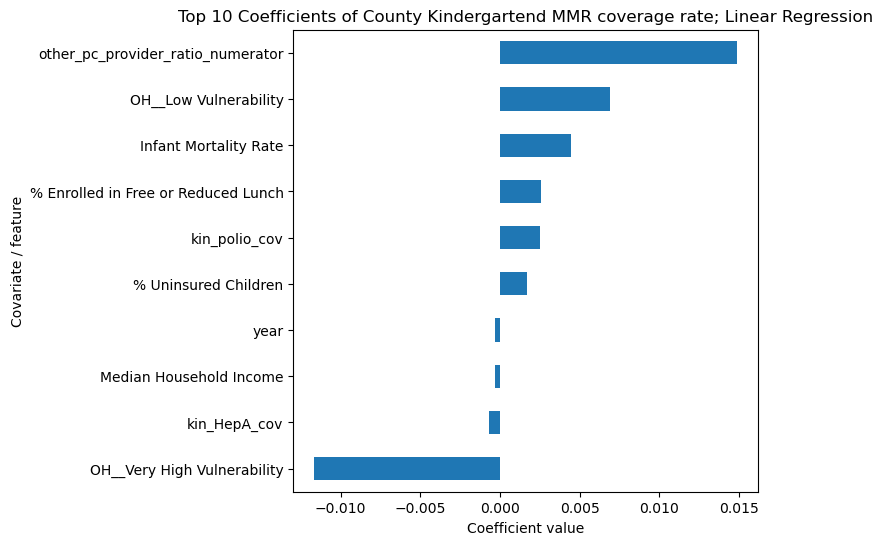

In [212]:
# Extract feature importance (coefficients from pipeline)
coefs = lr1.named_steps["regressor"].coef_.ravel()
coef_df = pd.DataFrame({
    "feature": selected_features,
    "coefficient": coefs
}).sort_values("coefficient", key=abs, ascending=True)

# Set index to feature name, extract coefficient series
coef_series = coef_df.set_index("feature")["coefficient"]
# Sort by absolute value
coef_series_sorted = coef_series.sort_values(key=abs, ascending=False)
# Select top 10 by magnitude
top10_coefs = coef_series_sorted.head(10)
print(top10_coefs)
# Plot horizontally
_ = top10_coefs.sort_values().plot.barh(figsize=(6,6))
plt.title("Top 10 Coefficients of County Kindergartend MMR coverage rate; Linear Regression")
plt.ylabel("Covariate / feature")
plt.xlabel("Coefficient value")

In [213]:
# try using model to predict coverage for new counties
y_pred = lr1.predict(X_test)

In [214]:
# instantiate a negative MSE scorer
neg_mse_scorer = make_scorer(mean_squared_error, greater_is_better=False)
neg_mse = neg_mse_scorer(lr1, X_test, y_test)
print(f"Negative MSE: {neg_mse}")
print(f"RMSE: {np.sqrt(-neg_mse)}")

Negative MSE: -0.0010233005127768533
RMSE: 0.031989068645036436


In [215]:
# calculate R squared 
lr1.score(X_test, y_test)


-0.0316592451427955

Dismal score on the training and test data sets.

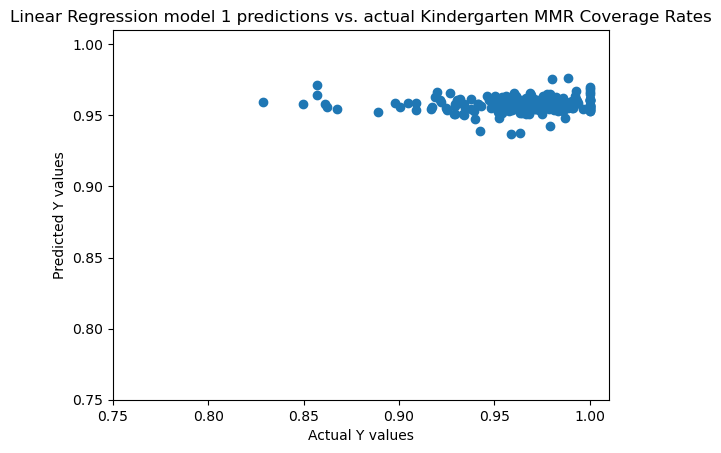

In [216]:
plt.scatter(y_test,y_pred)
# Set axis limits starting at 0.75
plt.xlim(0.75, 1.01)  # Add 5% padding
plt.ylim(0.75, 1.01)
plt.xlabel("Actual Y values")
plt.ylabel("Predicted Y values")
plt.title("Linear Regression model 1 predictions vs. actual Kindergarten MMR Coverage Rates")
plt.show()

THis looks like a pretty poor model, doesn't seem to be much relationship at all between the actual values and predicted values, which makes sense given the R squared value was only about 5%

#### Create data sets to run model for each year separately

From the group split data sets, create four new data sets to run the model separately on each year and see how feature inmportance may have shifted across the four years.

In [217]:
# split the train/test dfs by year
print("X_train shape", X_train_df.shape,
     "\ny_train shape", y_train_df.shape,
     "\nX_test shape", X_test_df.shape,
     "\ny_test shape", y_test_df.shape
     )

X_train shape (797, 41) 
y_train shape (797, 1) 
X_test shape (199, 41) 
y_test shape (199, 1)


In [218]:
# make yearly masks for training data matrix
X_2023_mask = X_train_df['year']==2023
X_2022_mask = X_train_df['year']==2022
X_2021_mask = X_train_df['year']==2021
X_2020_mask = X_train_df['year']==2020

X_train_2023 = X_train_df.loc[X_2023_mask,:]
X_train_2022 = X_train_df.loc[X_2022_mask,:]
X_train_2021 = X_train_df.loc[X_2021_mask,:]
X_train_2020 = X_train_df.loc[X_2020_mask,:]

y_train_2023 = y_train_df.loc[X_2023_mask,:]
y_train_2022 = y_train_df.loc[X_2022_mask,:]
y_train_2021 = y_train_df.loc[X_2021_mask,:]
y_train_2020 = y_train_df.loc[X_2020_mask,:]

print("Shape of 2023 dfs:", X_train_2023.shape, y_train_2023.shape)
print("Shape of 2022 dfs:", X_train_2022.shape, y_train_2022.shape)
print("Shape of 2021 dfs:", X_train_2021.shape, y_train_2021.shape)
print("Shape of 2020 dfs:", X_train_2020.shape, y_train_2020.shape)

Shape of 2023 dfs: (200, 41) (200, 1)
Shape of 2022 dfs: (198, 41) (198, 1)
Shape of 2021 dfs: (199, 41) (199, 1)
Shape of 2020 dfs: (200, 41) (200, 1)


In [219]:
# make yearly masks for test data 
X_2023_mask = X_test_df['year']==2023
X_2022_mask = X_test_df['year']==2022
X_2021_mask = X_test_df['year']==2021
X_2020_mask = X_test_df['year']==2020

X_test_2023 = X_test_df.loc[X_2023_mask,:]
X_test_2022 = X_test_df.loc[X_2022_mask,:]
X_test_2021 = X_test_df.loc[X_2021_mask,:]
X_test_2020 = X_test_df.loc[X_2020_mask,:]

y_test_2023 = y_test_df.loc[X_2023_mask,:]
y_test_2022 = y_test_df.loc[X_2022_mask,:]
y_test_2021 = y_test_df.loc[X_2021_mask,:]
y_test_2020 = y_test_df.loc[X_2020_mask,:]

print("Shape of 2023 dfs:", X_test_2023.shape, y_test_2023.shape)
print("Shape of 2022 dfs:", X_test_2022.shape, y_test_2022.shape)
print("Shape of 2021 dfs:", X_test_2021.shape, y_test_2021.shape)
print("Shape of 2020 dfs:", X_test_2020.shape, y_test_2020.shape)

Shape of 2023 dfs: (49, 41) (49, 1)
Shape of 2022 dfs: (50, 41) (50, 1)
Shape of 2021 dfs: (50, 41) (50, 1)
Shape of 2020 dfs: (50, 41) (50, 1)


In [220]:
# create pipeline and fit to data for 2020 data
lr12020 = Pipeline([
    ('feature_selection', SelectKBest(score_func=score_func, k=10)), # select top 10 features
    ("regressor", LinearRegression())
])

In [221]:
lr12020.fit(X_train, y_train)

Pipeline(steps=[('feature_selection',
                 SelectKBest(score_func=<function f_regression at 0x11745e840>)),
                ('regressor', LinearRegression())])

In [222]:
# Get the SelectKBest step from your pipeline
selector = lr12020.named_steps["feature_selection"]  
# Get boolean mask of selected features (True = selected, False = not selected)
selected_mask = selector.get_support()
# Get the names of the selected features
selected_features = [feature_names[i] for i, selected in enumerate(selected_mask) if selected]

In [223]:
# Extract feature importance (coefficients from pipeline)
coefs = lr12020.named_steps["regressor"].coef_.ravel()
coef_df_2020 = pd.DataFrame({
    "feature": selected_features,
    "coefficient": coefs
}).sort_values("coefficient", key=abs, ascending=True)

# Set index to feature name, extract coefficient series
coef_series_2020 = coef_df_2020.set_index("feature")["coefficient"]
# Sort by absolute value
coef_series_2020_sorted = coef_series_2020.sort_values(key=abs, ascending=False)
# Select top 10 by magnitude
top10_coefs_2020 = coef_series_2020_sorted.head(10)
print(top10_coefs_2020)

feature
other_pc_provider_ratio_numerator      0.014891
OH__Very High Vulnerability           -0.011653
OH__Low Vulnerability                  0.006886
Infant Mortality Rate                  0.004467
% Enrolled in Free or Reduced Lunch    0.002564
kin_polio_cov                          0.002524
% Uninsured Children                   0.001707
kin_HepA_cov                          -0.000662
Median Household Income               -0.000321
year                                  -0.000296
Name: coefficient, dtype: float64


### Dummy Regressor

In [366]:
dummy = DummyRegressor(strategy='mean')
dummy.fit(X_train, y_train)
dummy_score = dummy.score(X_train, y_train)
print(f"Dummy model R²: {dummy_score}")

Dummy model R²: 0.0


### OLS

OLS cannot be directly inserted into a pipeline, create a wrapper for this

In [230]:
class SMWrapper(BaseEstimator, RegressorMixin):
    """Wrapper for statsmodels OLS to work with sklearn pipelines"""
    def __init__(self, add_constant=True):
        self.add_constant = add_constant
    
    def fit(self, X, y):
        if self.add_constant:
            X = sm.add_constant(X)
        self.model_ = sm.OLS(y, X).fit()
        return self
    
    def predict(self, X):
        if self.add_constant:
            X = sm.add_constant(X)
        return self.model_.predict(X)


In [231]:
# Create pipeline with the wrapper
ols1 = Pipeline([
    ('feature_selection', SelectKBest(score_func=score_func, k=10)), # Select top 5 features
    ("regressor", SMWrapper(add_constant=True))
])

In [224]:
# Remember that to perform OLS, a constant is added to X_train  and X_test 
# X_train = sm.add_constant(X_train) # adds column (index 0) filled with 1’s.
# np.unique(X_train[:, 0])
# X_test = sm.add_constant(X_test)

X_train shape: (797, 40)
X_train shape after adding constant: (797, 41)


array([1.])

In [234]:
ols1.fit(X_train, y_train)
ols1_results = ols1.named_steps['regressor'].model_
print(ols1_results.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.026
Model:                            OLS   Adj. R-squared:                  0.013
Method:                 Least Squares   F-statistic:                     2.072
Date:                Sat, 27 Dec 2025   Prob (F-statistic):             0.0244
Time:                        21:42:49   Log-Likelihood:                 1387.7
No. Observations:                 797   AIC:                            -2753.
Df Residuals:                     786   BIC:                            -2702.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.9543      0.002    455.819      0.0

In [ ]:
# Fit the model 
#ols1_results = ols1.fit()
#ols1_results.summary()

Result summary showed small R squared of only 0.5

In [235]:
print(f"R-squared: {ols1_results.rsquared:.4f}")
print(f"Adjusted R-squared: {ols1_results.rsquared_adj:.4f}")
print(f"MSE: {ols1_results.mse_resid:.4f}")
print(f"RMSE: {np.sqrt(ols1_results.mse_resid):.4f}")

R-squared: 0.0257
Adjusted R-squared: 0.0133
MSE: 0.0018
RMSE: 0.0427


Performed much better on test data. Regularization is probably helping prevent overfitting.

**Question**: If my primary research question is interested in predictors, would i look at the coefficients from the model estimates on training data or on test data?

Take them from training set fitting, more data. But still report how well model generalizes

In [285]:
# Extract coefficients
coefs = ols1_results.params  # pandas Series with index = feature names
coefs = coefs[1:] # slice off first column of array which is the constant we added
coefs.shape 

(10,)

In [282]:
# Get the SelectKBest step from your pipeline
selector = ols1.named_steps["feature_selection"]  
# Get boolean mask of selected features (True = selected, False = not selected)
selected_mask = selector.get_support()
# Get the names of the selected features
selected_features = [feature_names[i] for i, selected in enumerate(selected_mask) if selected]

In [283]:
selector

SelectKBest(score_func=<function f_regression at 0x11745e840>)

In [284]:
selected_features

['# Primary Care Physicians',
 '% Children in Poverty',
 '# Uninsured Children',
 '% Uninsured Children',
 '% Food Insecure',
 'Median Household Income',
 '% Less Than 18 Years of Age',
 'other_pc_provider_ratio_numerator',
 'OH__Very High Vulnerability',
 'OH__Moderate Concern']

In [239]:
len(selected_features)

10

In [286]:
# Set index to feature name, extract coefficient series
coef_df = pd.DataFrame({'coefficients': coefs}, index = selected_features)
coef_df['coef_magnitude'] = abs(coef_df['coefficients'])
coef_df.sort_values(by=['coef_magnitude'], ascending=False)

,coefficients,coef_magnitude
other_pc_provider_ratio_numerator,0.014891,0.014891
OH__Moderate Concern,-0.011653,0.011653
OH__Very High Vulnerability,0.006886,0.006886
# Primary Care Physicians,0.004467,0.004467
% Uninsured Children,0.002564,0.002564
% Less Than 18 Years of Age,0.002524,0.002524
% Children in Poverty,0.001707,0.001707
Median Household Income,-0.000662,0.000662
# Uninsured Children,-0.000321,0.000321
% Food Insecure,-0.000296,0.000296


<Axes: >

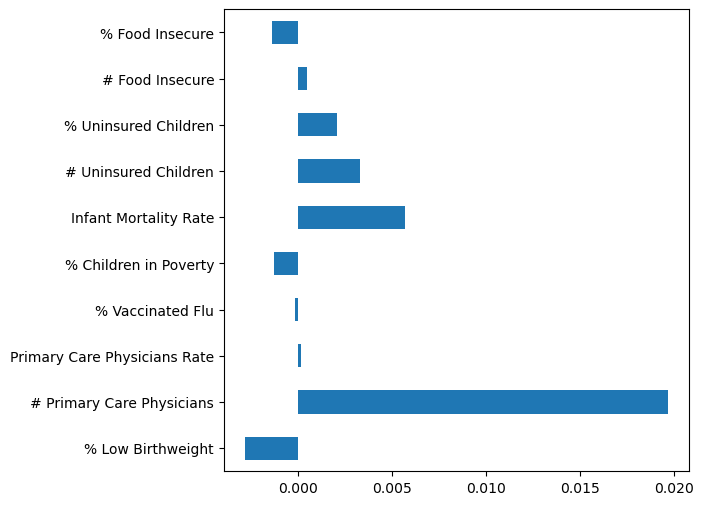

In [437]:
coef_df_top10 = coef_df['coefficients'].head(10)
# Plot horizontally
coef_df_top10.plot.barh(figsize=(6,6))

In [438]:
# predict model results on X_test
y_pred = ols1_results.predict(X_test)

Text(0, 0.5, 'Predicted')

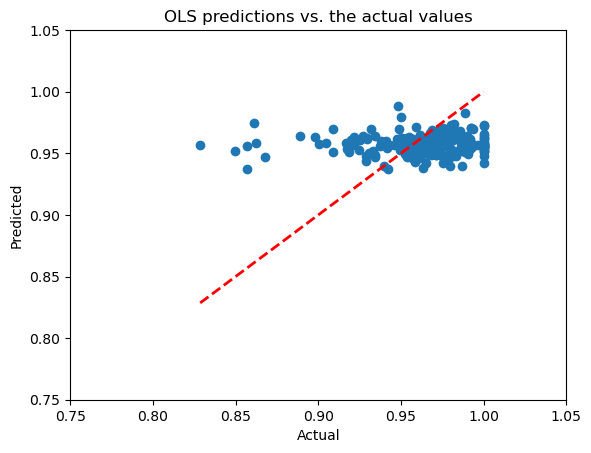

In [439]:
# Build a scatterplot
plt.scatter(y_test, y_pred)
# Get the range of your data to draw the line 
line_start = min(y_test.min(), y_pred.min())
line_end = max(y_test.max(), y_pred.max())

# Add a line for perfect correlation. 
plt.plot([line_start, line_end], [line_start, line_end], color='red', linestyle='--', linewidth=2, label='Perfect prediction')

# Set axis limits starting at 0.75
plt.xlim(0.75, line_end * 1.05)  # Add 5% padding
plt.ylim(0.75, line_end * 1.05)

# Label it nicely
plt.title("OLS predictions vs. the actual values")
plt.xlabel ("Actual")
plt.ylabel("Predicted")

In [ ]:
# fit model on test data

In [243]:
ols1.fit(X_test, y_test)
ols1test_results = ols1.named_steps['regressor'].model_
# print(ols1test_results.summary())

In [244]:
print(f"R-squared: {ols1test_results.rsquared:.4f}")
print(f"Adjusted R-squared: {ols1test_results.rsquared_adj:.4f}")
print(f"MSE: {ols1test_results.mse_resid:.4f}")
print(f"RMSE: {np.sqrt(ols1test_results.mse_resid):.4f}")

R-squared: 0.0519
Adjusted R-squared: 0.0015
MSE: 0.0010
RMSE: 0.0316


In [245]:
# Extract coefficients
coefs = ols1test_results.params  # pandas Series with index = feature names
coefs = coefs[1:] # slice off first column of array which is the constant we added
coefs.shape 

(10,)

In [248]:
# Get the SelectKBest step from your pipeline
selector = ols1.named_steps["feature_selection"]  
# Get boolean mask of selected features (True = selected, False = not selected)
selected_mask = selector.get_support()
# Get the names of the selected features
selected_features = [feature_names[i] for i, selected in enumerate(selected_mask) if selected]
print(len(selected_features))

10


In [249]:
# Set index to feature name, extract coefficient series
coef_df = pd.DataFrame({'coefficients': coefs}, index = selected_features)
coef_df['coef_magnitude'] = abs(coef_df['coefficients'])
coef_df.sort_values(by=['coef_magnitude'], ascending=False)

,coefficients,coef_magnitude
OH__Moderate Concern,0.023867,0.023867
# Uninsured Children,0.005082,0.005082
% Uninsured Children,-0.004532,0.004532
Median Household Income,-0.004245,0.004245
% Food Insecure,0.004054,0.004054
# Primary Care Physicians,-0.002834,0.002834
% Less Than 18 Years of Age,0.002631,0.002631
OH__Very High Vulnerability,-0.002135,0.002135
% Children in Poverty,0.001219,0.001219
other_pc_provider_ratio_numerator,-0.000295,0.000295


interesting to see that most import covariates differs slightly from the training to test set. Uninsurance and the SVI categories are still big drivers of immunization coverate, but the median household income is now in the top five as well as the % of the population that is food insecure.

### Ridge

In [291]:
# Create pipeline with the wrapper
ridge1 = Pipeline([
    ('feature_selection', SelectKBest(score_func=score_func, k=10)), # Select top 5 features
    ("ridge", Ridge())
])

In [292]:
# parameter grid for pipeline object
# note that dictionary keys must match the pipeline steps specified above
param_grid = {
    'feature_selection__k': [5, 10, 20, 30, 'all'], 
    'ridge__alpha': [0.1, 1, 10, 100, 1000, 10000, 1000000]
}

In [445]:
# set hyperparameter range
#param_grid = {"alpha": [0.1, 1.0, 10.0, 100.0, 1000.0, 10000.0, 1000000]}
#ridge = Ridge()
#ridge_cv = GridSearchCV(ridge, param_grid, cv=kf)

In [293]:
# define cross validation object for 
ridge_cv = GridSearchCV(
    ridge1,
    param_grid,
    cv=kf,
    scoring={
        'mse': 'neg_mean_squared_error',
        'r2': 'r2'
    },
    refit='mse', # use MSE to choose best estimator
    n_jobs=-1
)

GridSearchCV
 └── best_estimator_  ← Pipeline
      ├── feature_selection (SelectKBest)
      └── ridge (Ridge)

In [294]:
# fit to training data
ridge_cv.fit(X_train, y_train)

GridSearchCV(cv=KFold(n_splits=5, random_state=1, shuffle=True),
             estimator=Pipeline(steps=[('feature_selection',
                                        SelectKBest(score_func=<function f_regression at 0x11745e840>)),
                                       ('ridge', Ridge())]),
             n_jobs=-1,
             param_grid={'feature_selection__k': [5, 10, 20, 30, 'all'],
                         'ridge__alpha': [0.1, 1, 10, 100, 1000, 10000,
                                          1000000]},
             refit='mse',
             scoring={'mse': 'neg_mean_squared_error', 'r2': 'r2'})

In [295]:
# check optimal parameters
print("Tuned ridge paramaters: {}".format(ridge_cv.best_params_))
# check training score
print("Tuned ridge neg mean squared score: {}".format(round(math.sqrt(-ridge_cv.best_score_),5))) # negative sq root of the negative mean squared error


Tuned ridge paramaters: {'feature_selection__k': 5, 'ridge__alpha': 1000000}
Tuned ridge neg mean squared score: 0.04298


Best hyperparameter showed that alpha was 1 million, so there is a huge penalty put on larger coefficients in this model. Remember that as alpha increases, Rsquared (performance) decreases.

In [296]:
# extract the R squared of the model with the best model (best mse)
best_idx = ridge_cv.best_index_
best_r2 = ridge_cv.cv_results_['mean_test_r2'][best_idx]
print(best_r2)

-0.0010388632696436417


In [ ]:
# Extract coefficients
#coefs = ridge_cv.params  # pandas Series with index = feature names
#coefs = coefs[1:] # slice off first column of array which is the constant we added
#coefs.shape 

In [303]:
# Get the SelectKBest step from your pipeline to examine features
best_pipe = ridge_cv.best_estimator_
selector = best_pipe.named_steps["feature_selection"]  
# Get boolean mask of selected features (True = selected, False = not selected)
selected_mask = selector.get_support()
# Get the names of the selected features
selected_features = [feature_names[i] for i, selected in enumerate(selected_mask) if selected]
print(len(selected_features))
print(selected_features)

5
['# Uninsured Children', '% Enrolled in Free or Reduced Lunch', 'Population', 'OH__Moderate Vulnerability', 'OH__Very Low Vulnerability']


In [305]:
# extract model from pipeline to look at coefficients
ridge_model = best_pipe.named_steps['ridge']

In [ ]:
# examine coefficients from fitting on training data
#coefs = best_estimator.coef_.ravel()
#print(f"Array length from model {len(coefs)}") # first item appears to be 0.... perhaps an intercept?
#coefs = coefs[1:]
#print(f"Array length after removing first coefficient of zero {len(coefs)}")

In [311]:
coef_df = pd.DataFrame({'coefficients': ridge_model.coef_}, index = selected_features)
coef_df['coef_magnitude'] = abs(coef_df['coefficients'])
coef_df.sort_values(by=['coef_magnitude'], ascending=False)
coef_df_top10 = coef_df['coefficients'].head(10)
coef_df

,coefficients,coef_magnitude
# Uninsured Children,1.371727e-06,1.371727e-06
% Enrolled in Free or Reduced Lunch,-1.777136e-06,1.777136e-06
Population,2.083942e-06,2.083942e-06
OH__Moderate Vulnerability,6.794894e-07,6.794894e-07
OH__Very Low Vulnerability,-8.100769e-07,8.100769e-07


<Axes: >

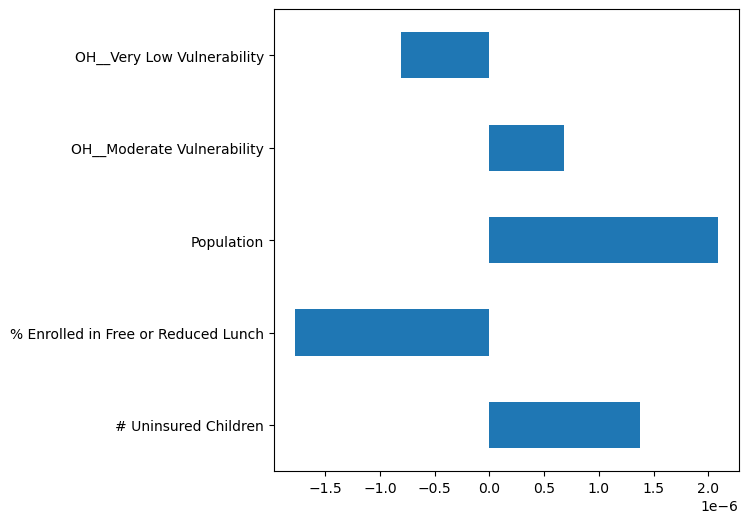

In [312]:
# Plot horizontally
coef_df_top10.plot.barh(figsize=(6,6))

Fit the model on test data

In [323]:
y_pred = best_pipe.predict(X_test)

In [331]:
r2 = best_pipe.score(X_test, y_test)
print(f"Test R²: {r2_test:.4f}")
mse = mean_squared_error(y_test, y_pred)
print(f"Test MSE: {mse:.4f}")


Test R²: -0.0339
Test MSE: 0.0010


Examine performance on test data visually

Text(0, 0.5, 'Predicted')

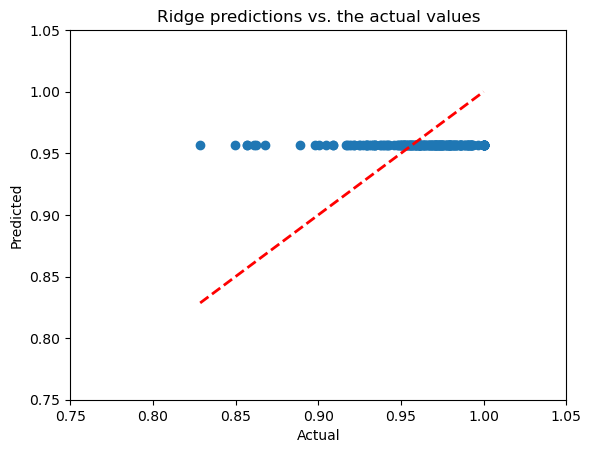

In [332]:
# Build a scatterplot
plt.scatter(y_test, y_pred)
# Get the range of your data to draw the line 
line_start = min(y_test.min(), y_pred.min())
line_end = max(y_test.max(), y_pred.max())

# Add a line for perfect correlation. 
plt.plot([line_start, line_end], [line_start, line_end], color='red', linestyle='--', linewidth=2, label='Perfect prediction')

# Set axis limits starting at 0.5
plt.xlim(0.75, line_end * 1.05)  # Add 5% padding
plt.ylim(0.75, line_end * 1.05)

# Label it nicely
plt.title("Ridge predictions vs. the actual values")
plt.xlabel ("Actual")
plt.ylabel("Predicted")

Test Ridge model on Test data

Model did better on the test data than on the train data. Possibly it is under fitting? 

**Question**: Why did the best score during tuning occur when there was the largest alpha (penalty) on high coefficients which I didn't know was possible while underfitting. 

### XGBoost

In [334]:
# Create the pipeline
xg_pipeline = Pipeline([
    ('feature_selection', SelectKBest(score_func=score_func, k=10)),
    ('regressor', xgb.XGBRegressor())
])

In [335]:
# Define parameter grid - use double underscore to specify pipeline step
param_grid = {
    'regressor__alpha': [0.1, 1.0, 10.0, 100.0, 1000.0, 10000.0, 1000000],
    'regressor__max_depth': [2, 6, 10, 14],
    'regressor__eta': [0.5, 1.0, 1.5]
}

In [337]:
#xg = xgb.XGBRegressor()
# learning_rate (alias eta): Controls the step size, with smaller values preventing overfitting.
#param = {'max_depth': 2, 'eta': 1, 'objective': 'reg:squarederror'}
#param_grid = {"alpha": [0.1, 1.0, 10.0, 100.0, 1000.0, 10000.0, 1000000],
#             "max_depth": [2,6, 10, 14],
#             "eta": [0.5, 1.0, 1.5]
#             }


In [338]:
xgboost_cv = GridSearchCV(xg_pipeline, param_grid, cv=kf, 
                          scoring='neg_mean_squared_error', verbose=1)

In [343]:
#xgboost_cv = GridSearchCV(xg, param_grid, cv=kf) 
xgboost_cv.fit(X_train, y_train)
# no transform or fit_transform method on XGBoost
xgboost_cv.score(X_train, y_train)

Fitting 5 folds for each of 84 candidates, totalling 420 fits


-0.0018470529817251231

In [346]:
# Get best model and results
best_model = xgboost_cv.best_estimator_
# check optimal parameters
print("Tuned ridge paramaters: {}".format(xgboost_cv.best_params_))
# check training score
print("Tuned ridge root mean squared error score: {}".format(round(math.sqrt(-xgboost_cv.best_score_),5))) # negative sq root of the negative mean squared error


Tuned ridge paramaters: {'regressor__alpha': 10.0, 'regressor__eta': 0.5, 'regressor__max_depth': 2}
Tuned ridge root mean squared error score: 0.04298


In [349]:
# Use the best model to predict and calculate R²
# Get R² on training data (using CV best estimator)
best_model = xgboost_cv.best_estimator_
train_r2 = best_model.score(X_train, y_train)
print(f"Train R²: {train_r2:.10f}")

Train R²: -0.0000000000


In [488]:
#xg.score(X_test, y_test)

-0.37752410517877766

Horrible generalization with negative R squared value!! Definite overfitting problem.

In [354]:
# Get the SelectKBest step from your pipeline to examine features
selector = best_model.named_steps["feature_selection"]  
# Get boolean mask of selected features (True = selected, False = not selected)
selected_mask = selector.get_support()
# Get the names of the selected features
selected_features = [feature_names[i] for i, selected in enumerate(selected_mask) if selected]
print(len(selected_features))
print(selected_features)

10
['# Uninsured Children', '# Food Insecure', '% Enrolled in Free or Reduced Lunch', 'Population', '% Broadband Access', 'kin_HepB_cov', 'kin_varic_cov', 'OH__Low Vulnerability', 'OH__Moderate Vulnerability', 'OH__Very Low Vulnerability']


In [359]:
# extract model from pipeline to look at coefficients
xgboost_model = best_model.named_steps['regressor']

In [360]:
xgboost_model.feature_importances_

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32)

In [362]:
importance_df = pd.DataFrame({'coefficients': xgboost_model.feature_importances_}, index = selected_features)
# nothing to plot

<Axes: >

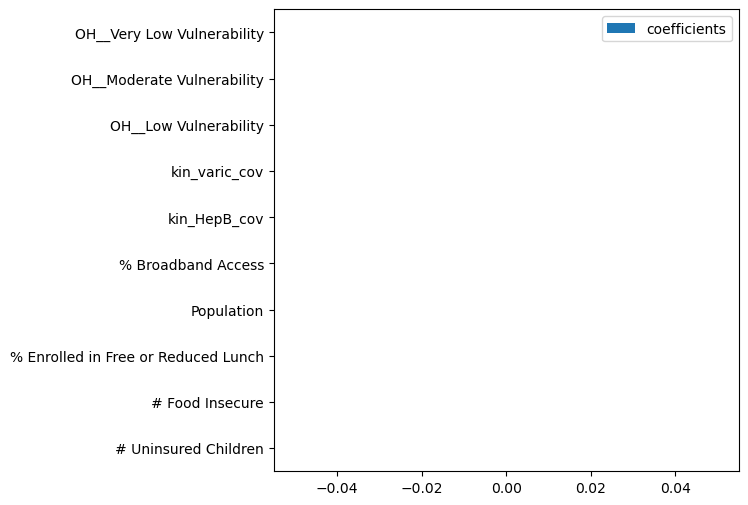

In [363]:
# Plot horizontally
importance_df.plot.barh(figsize=(6,6))

No better than a dummy regressor

### RandomForest

In [482]:
rf = RandomForestRegressor(random_state = 1,n_jobs=-1)
param_grid = {"min_samples_leaf": [1, 3, 5],
             "max_depth": [2,6, 10, 14],
             "min_samples_split": [2, 5, 8],
             "max_features": ["sqrt", "log2"],
             "n_estimators":[100, 150, 200],
             }
rf_cv = GridSearchCV(rf, param_grid, cv=kf)
rf.fit(X_train, y_train)

/var/folders/zg/81kjn_8j4692tlw3f6q33h6w0000gq/T/ipykernel_50701/174356750.py:9: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  rf.fit(X_train, y_train)


RandomForestRegressor(n_jobs=-1, random_state=1)

In [483]:
rf.score(X_train, y_train)

0.8330217853974615

In [484]:
rf.score(X_test, y_test)

-0.19635747193352815

Negative R² - model is severely overfitting the training data and fails to generalize to unseen data

In [ ]:
Of the various models tried, Ridge model has generalized best to new data.

# 4. Temporal Split - Investigate model capacity to predict future MMR coverage

## 4a. Load data


In [491]:
os.chdir('/Users/grace/Documents/GitHubRepos/capstone2_immunization/processed_data/temporal_split/')

In [492]:
print(os.getcwd())  # get current working directory

/Users/grace/Documents/GitHubRepos/capstone2_immunization/processed_data/temporal_split


In [493]:
def import_multiple_csv_to_pandas(filename):
    df = pd.read_csv(filename) 
    print(f"\nDataFrame before conversion:")
    #print(f"Dtypes:\n{df.dtypes}\n")
    print(f"NaN count per column:\n{df.isna().sum()}")
    print(f"Total NaN: {df.isna().sum().sum()}")
    return df

Update file names throughout code....
**Question** How do i structure analysis when my X2, y set is my hold-out data set.
should i do cross-validation on training and then a test without CV on the X2 and y2?

In [496]:
file_names = ["X1_train.csv", 
              "y1_train.csv", 
              "X2.csv", 
              "y1_test.csv",
              "y2.csv"]

In [495]:
# Import data to data frames
X1_train_df = import_multiple_csv_to_pandas(file_names[0])
y_train_df = import_multiple_csv_to_pandas(file_names[1])
X_test_df = import_multiple_csv_to_pandas(file_names[2])
y_test_df = import_multiple_csv_to_pandas(file_names[3])

FileNotFoundError: [Errno 2] No such file or directory: 'X_train.csv'

In [ ]:
# Convert only y_test and y_train to numpy arrays
y_test = y_test_df.to_numpy()
y_train = y_train_df.to_numpy()

print("y_test array:")
print(" Shape:", y_test_array.shape)
print(" Dtype:", y_test_array.dtype)

print("y_train array:")
print(" Shape:", y_train_array.shape)
print(" Dtype:", y_train_array.dtype)

In [ ]:
# check to see if country_name is in the X_train file, will need this for imputation fxn
X_train_df.index
'county_name' in (X_train_df.columns)

# extract index to X_train
feature_names = X_train_df.columns.to_list()

In [ ]:
# apply standardizer fxn to X_train and X_test
X_train_processed, X_test_processed = standardizze(X_train_df, X_test_df)

In [ ]:
# Apply the impute_please fxn to X_train and X_test
# remember the impute_please function requires 'county_name' as a column
X_train_processed, X_test_processed = impute_please(X_train_processed, X_test_processed, 0.03)

#### Convert index to numeric and remove county_name before modeling

In [ ]:
type(X_train_processed)

In [ ]:
# Process X_train and X_test
# Make sure there indices are numeric before modeling, delete 'column', rename and convert to numpy

for df in [X_train_processed]:
    print(f"Dataframe has county as a column BEFORE modification? {['county_name'] in df.columns.to_list()}")
    df = df.sort_values(by = ['county_name','year'])
    df.drop(columns = ['county_name'], axis =1, inplace =True)
    df = df.reset_index(drop=True)
    print(df.index)
    print(f"Dataframe has county as a column AFTER modification? {['county_name'] in df.columns.to_list()}")
    print(df.index.to_list()[5])
    X_train = df.to_numpy()

for df in [X_test_processed]:
    print(f"Dataframe has county as a column BEFORE modification? {['county_name'] in df.columns.to_list()}")
    df = df.sort_values(by = ['county_name','year'])
    df.drop(columns = ['county_name'], axis =1, inplace =True)
    df = df.reset_index(drop=True)
    print(df.index)
    print(f"Dataframe has county as a column AFTER modification? {['county_name'] in df.columns.to_list()}")
    print(df.index.to_list()[5])
    X_test = df.to_numpy()

In [ ]:
# last data type and shape checks
print(f"X_train type: {type(X_train)}\nX_test type is{type(X_test)}.")
print(f"X_train shape: {X_train.shape}\nX_test type is{X_test.shape}.")

print(f"y_train type: {type(y_train)}\ny_test type is{type(y_test)}.")
print(f"y_train type: {y_train.shape}\ny_test type is{y_test.shape}.")

feature_names.remove('county_name')
print(len(feature_names))

## 4b. Models

In [ ]:
# specify cross validation setup
kf = KFold(n_splits=5, shuffle=True, random_state=1)
